In [74]:
import argparse
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib
from oak.model_utils import oak_model, save_model
from oak.utils import get_model_sufficient_statistics, get_prediction_component
from oak.plotting_utils import *
from oak.oak_kernel import get_list_representation, KernelComponenent, OAKKernel
from scipy import io
from sklearn.model_selection import KFold
from sklearn.decomposition import PCA
from pathlib import Path

In [75]:
X_LOWER = -5
X_UPPER = 5

In [76]:
x1 = np.random.uniform(X_LOWER,X_UPPER,100)
x2 = np.random.uniform(X_LOWER,X_UPPER,100)
x3 = np.random.uniform(X_LOWER,X_UPPER,100)

# Not dependent on x3
f1 = 5 * x1 + x2 ** 2 + x1 * x2

# No second order terms
f2 = np.cos(x1) + x2 + x3 ** 2 + 5 * x1 * x2 * x3

# all order terms
f3 = 3 * np.abs(x1) + 2 * x2 + np.exp(x3) + 2* x1 * x2 + 5 * np.sin(x1* x3) + 0.25 * x2 * x3 + 5 * x1 * x2 * x3

In [102]:
X_train = np.column_stack((x1, x2, x3))
print(f"X_train shape: {X_train.shape}")
F_train = np.column_stack((f1, f2, f3))
print(f"F shape: {F.shape}")

X_train shape: (100, 3)
F shape: (100, 3)


## PCGP

In [103]:
pca_obj = PCA(n_components=F_train.shape[1], svd_solver='full')
G_train = pca_obj.fit_transform(F_train)

emulator_models = [] 
for i in range(F_train.shape[1]):
    G_train_i = G_train[:,i].reshape(-1,1)
    oak_model_instance = oak_model(max_interaction_depth=X_train.shape[1],
                                  use_normalising_flow=True,
                                  use_sparsity_prior=True)
    
    oak_model_instance.fit(X_train, G_train_i)

    emulator_models.append(oak_model_instance)
    

indices of binary feature  []
indices of continuous feature  [0, 1, 2]
indices of categorical feature  []
[None, None, None]
Using sparsity prior


name,class,transform,prior,trainable,shape,dtype,value
GPR.kernel.kernels[0].base_kernel.lengthscales,Parameter,Sigmoid,,True,(),float64,1.1627
GPR.kernel.kernels[1].base_kernel.lengthscales,Parameter,Sigmoid,,True,(),float64,2.35125
GPR.kernel.kernels[2].base_kernel.lengthscales,Parameter,Sigmoid,,True,(),float64,1.1564
GPR.kernel.variances[0],Parameter,Softplus,Gamma,True,(),float64,0.00017
GPR.kernel.variances[1],Parameter,Softplus,Gamma,True,(),float64,0.03598
GPR.kernel.variances[2],Parameter,Softplus,Gamma,True,(),float64,0.04227
GPR.kernel.variances[3],Parameter,Softplus,Gamma,True,(),float64,16.7758
GPR.likelihood.variance,Parameter,Softplus + Shift,,True,(),float64,0.00046


Training took 1.4 seconds.
indices of binary feature  []
indices of continuous feature  [0, 1, 2]
indices of categorical feature  []
[None, None, None]
Using sparsity prior


name,class,transform,prior,trainable,shape,dtype,value
GPR.kernel.kernels[0].base_kernel.lengthscales,Parameter,Sigmoid,,True,(),float64,1.74241
GPR.kernel.kernels[1].base_kernel.lengthscales,Parameter,Sigmoid,,True,(),float64,1.96075
GPR.kernel.kernels[2].base_kernel.lengthscales,Parameter,Sigmoid,,True,(),float64,1.38824
GPR.kernel.variances[0],Parameter,Softplus,Gamma,True,(),float64,0.00093
GPR.kernel.variances[1],Parameter,Softplus,Gamma,True,(),float64,4.47899
GPR.kernel.variances[2],Parameter,Softplus,Gamma,True,(),float64,1.27857
GPR.kernel.variances[3],Parameter,Softplus,Gamma,True,(),float64,0.86582
GPR.likelihood.variance,Parameter,Softplus + Shift,,True,(),float64,0.01504


Training took 1.7 seconds.
indices of binary feature  []
indices of continuous feature  [0, 1, 2]
indices of categorical feature  []
[None, None, None]
Using sparsity prior


name,class,transform,prior,trainable,shape,dtype,value
GPR.kernel.kernels[0].base_kernel.lengthscales,Parameter,Sigmoid,,True,(),float64,1.39938
GPR.kernel.kernels[1].base_kernel.lengthscales,Parameter,Sigmoid,,True,(),float64,1.93526
GPR.kernel.kernels[2].base_kernel.lengthscales,Parameter,Sigmoid,,True,(),float64,1.47794
GPR.kernel.variances[0],Parameter,Softplus,Gamma,True,(),float64,0.00019
GPR.kernel.variances[1],Parameter,Softplus,Gamma,True,(),float64,4.16192
GPR.kernel.variances[2],Parameter,Softplus,Gamma,True,(),float64,0.05165
GPR.kernel.variances[3],Parameter,Softplus,Gamma,True,(),float64,0.1342
GPR.likelihood.variance,Parameter,Softplus + Shift,,True,(),float64,0.00618


Training took 1.3 seconds.


* Plotting Breaks when doing terms higher than 2nd order

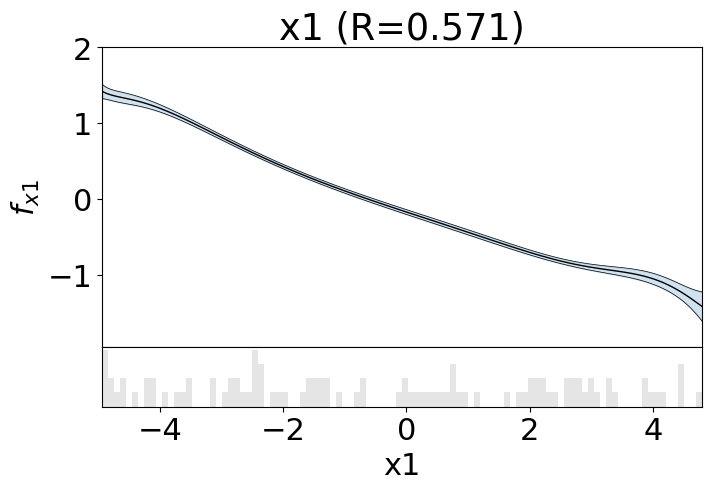

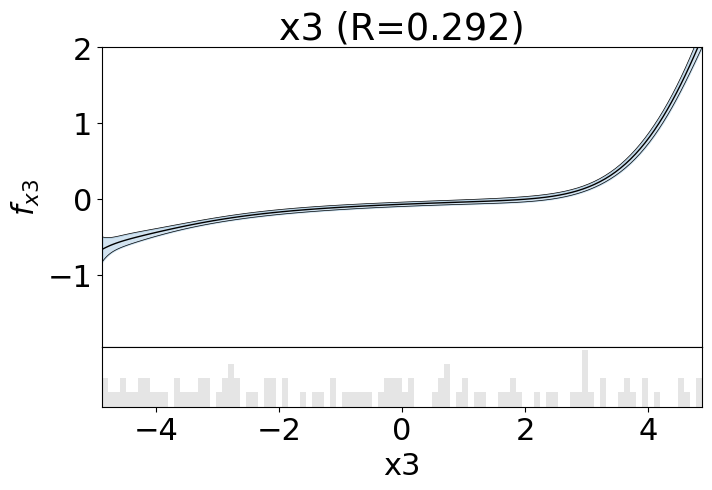

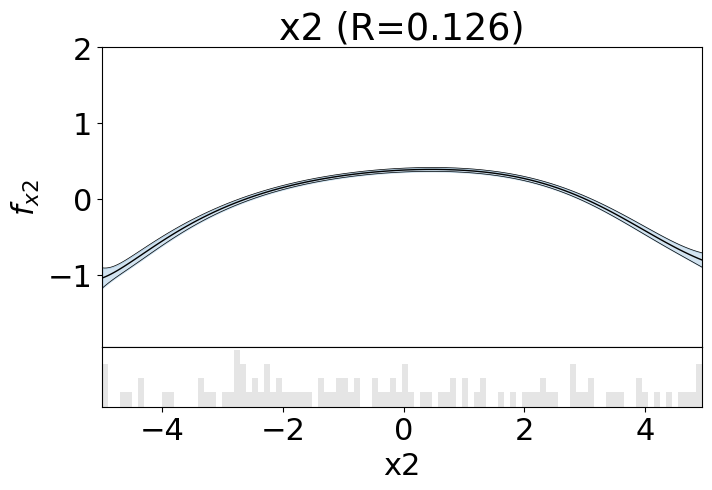

In [122]:
covariate_names = ["x1", "x2", "x3"]

emulator_models[2].plot(top_n=3,
                       semilogy=False,
                        X_columns=covariate_names)

$$ f_3 = 3|x_1| + 2x_2 + e^{x_3} + 2x_1x_2 + 5sin(x_1x_2) + 0.25x_2x_3 + 5x_1x_2x_3  $$

In [106]:
Phi = pca_obj.components_.T
Phi

array([[ 0.00451373,  0.47959743, -0.87747703],
       [-0.71870099, -0.6085704 , -0.33631971],
       [-0.69530462,  0.63216166,  0.34194023]])

In [199]:


target_feature_index = 2 # Index for x3
num_emulators = len(emulator_models) # Should match num_dims in this context
feature_names = [f"x{k+1}" for k in range(num_emulators)] # Example names

# Create a test grid for x3 in its original space
n_grid = 100
x3_plot_range_original = np.linspace(X_LOWER, X_UPPER, n_grid)

# Prepare a base input grid where other features are constant (scaled space)
# (Same grid creation logic as before)
X_train_scaled_full = emulator_models[0].X_scaled
mean_X_scaled = np.mean(X_train_scaled_full, axis=0)
X_grid_scaled = np.tile(mean_X_scaled, (n_grid, 1))
x3_inverse_transform = emulator_models[0]._get_x_inverse_transformer(target_feature_index)

if x3_inverse_transform:
    x3_plot_range_scaled = x3_inverse_transform(x3_plot_range_original)
    if not isinstance(x3_plot_range_scaled, np.ndarray):
        x3_plot_range_scaled = x3_plot_range_scaled.numpy()
    X_grid_scaled[:, target_feature_index] = x3_plot_range_scaled
else:
    print(f"Warning: No inverse transform found for feature {target_feature_index}.")
    X_grid_scaled[:, target_feature_index] = x3_plot_range_original


# --- Initialize accumulator for the sum ---
# Use float dtype for the accumulator
total_x3_effect = np.zeros((n_grid, num_emulators), dtype=float)


for i in range(num_emulators):
    print(f"--- Processing Emulator {i} (Output: PC Score {i}) ---")
    oak_model_instance = emulator_models[i]
    m = oak_model_instance.m # The underlying GPflow model
    original_kernel = m.kernel

    # --- Check Kernel ---
    if not hasattr(original_kernel, 'kernels') or not hasattr(original_kernel, 'variances'):
        print(f"Warning: Kernel for emulator {i} doesn't seem to be OAKKernel. Skipping.")
        continue

    effect_relative_to_const = np.zeros_like(x3_plot_range_original, dtype=float)
    const_pred_scalar = 0.0

    # --- Predict component and constant term ---
    try:
        # Create necessary KernelComponent objects
        kernel_comp = KernelComponenent(
             oak_kernel=original_kernel,
             iComponent_list=[target_feature_index], # Only x3 effect
             share_var_across_orders=oak_model_instance.share_var_across_orders
        )
        const_kernel_comp = KernelComponenent(
             oak_kernel=original_kernel,
             iComponent_list=[], # Empty list for constant
             share_var_across_orders=oak_model_instance.share_var_across_orders
        )

        # Predict constant baseline
        m.kernel = const_kernel_comp
        const_pred_scaled, _ = m.predict_f(X_grid_scaled[[0], :]) # Predict at one point
        const_pred_scalar = const_pred_scaled.numpy()[0, 0]

        # Predict x3 component effect
        m.kernel = kernel_comp
        pred_mean_scaled_comp, _ = m.predict_f(X_grid_scaled)
        pred_mean_scaled_comp = pred_mean_scaled_comp.numpy().flatten() # Make 1D

        # Calculate effect relative to baseline
        effect_relative_to_const = pred_mean_scaled_comp - const_pred_scalar

    except Exception as e:
         print(f"Error predicting for emulator {i}: {e}")
         # Keep effect_relative_to_const as zeros if prediction fails
         effect_relative_to_const = np.zeros_like(x3_plot_range_original, dtype=float)
    finally:
        m.kernel = original_kernel # IMPORTANT: Restore original kernel

    # --- Add to total sum ---
    total_x3_effect [:,i] =  effect_relative_to_const
    # --- End loop for emulator i ---


# --- Plot the summed effect ---
# plt.figure(figsize=(10, 6))
# plt.plot(x3_plot_range_original, total_x3_effect, label=f'Summed Effect of {feature_names[target_feature_index]}')

# # Add plot labels and legend
# plt.title(f"Summed First-Order Effect of {feature_names[target_feature_index]} across all Input PC Emulators")
# plt.xlabel(f"Original {feature_names[target_feature_index]} Value")
# plt.ylabel("Summed Predicted Effect Contribution\n(Across all PC Scores)")
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.show()

# You can also store the final sum if needed:
# predicted_effects[('sum', target_feature_index)] = total_x3_effect

--- Processing Emulator 0 (Output: PC Score 0) ---
--- Processing Emulator 1 (Output: PC Score 1) ---
--- Processing Emulator 2 (Output: PC Score 2) ---


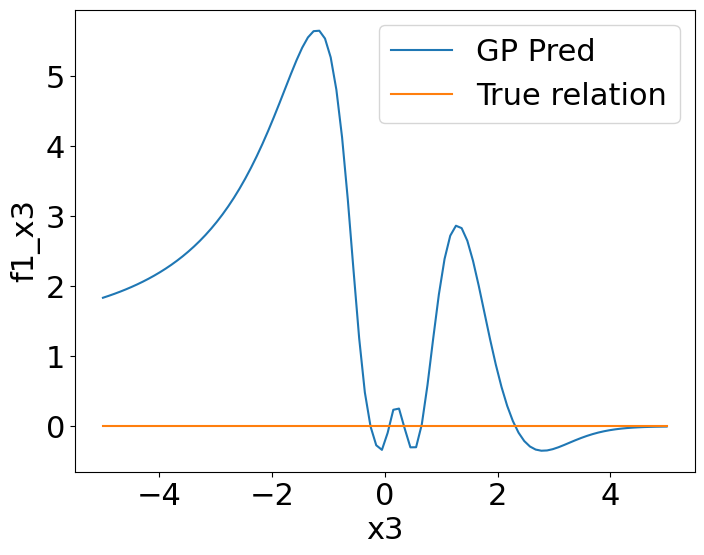

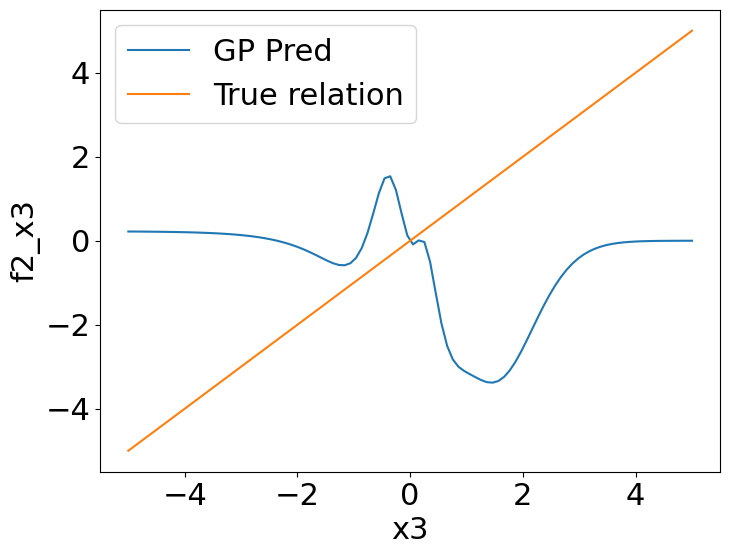

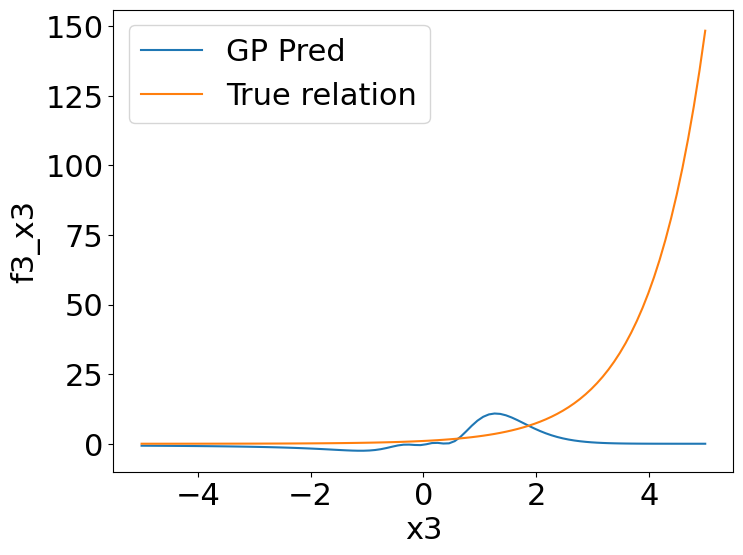

In [203]:
f_first_order = total_x3_effect @ Phi.T

for i in range(f_first_order.shape[1]):
    plt.figure(figsize=(8,6))
    plt.plot(x3_plot_range_original, f_first_order[:,i], label='GP Pred')
    if i == 0:
        true_f = np.zeros_like(x3_plot_range_original)
    elif i == 1:
        true_f = x3_plot_range_original
    else:
        true_f = np.exp(x3_plot_range_original)
        
    plt.plot(x3_plot_range_original, true_f ,label='True relation')
    plt.xlabel('x3')
    plt.ylabel(f'f{i+1}_x3')

    plt.legend()

plt.show()

--- Processing Emulator 0 (Output: PC Score 0) ---
--- Processing Emulator 1 (Output: PC Score 1) ---
--- Processing Emulator 2 (Output: PC Score 2) ---


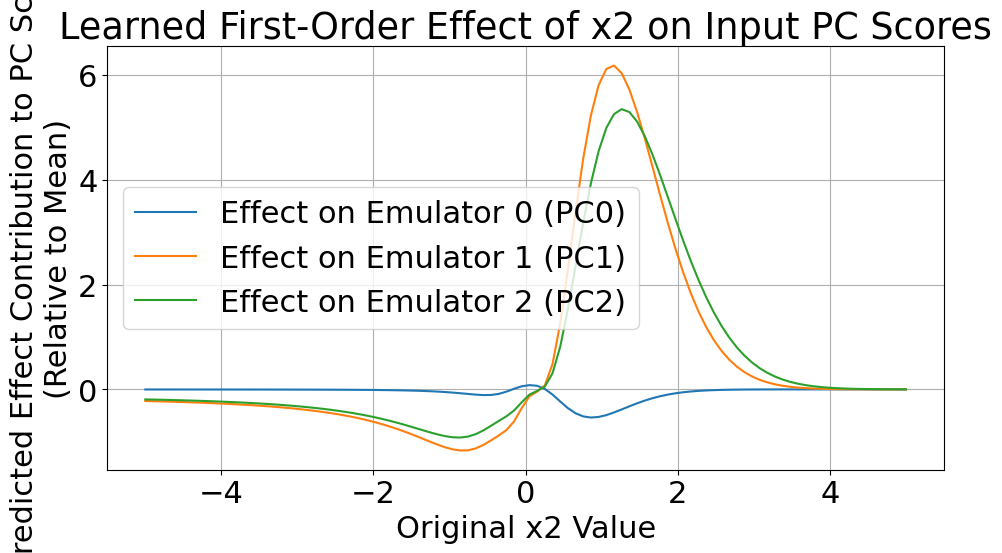

In [207]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from oak.utils import get_model_sufficient_statistics # Assuming this is importable


# --- (Previous setup code remains the same) ---

# --- Initialize storage for the effects ---
all_x3_effects = np.zeros((n_grid, num_emulators), dtype=float)

# --- Loop through each emulator model ---
for i in range(num_emulators):
    print(f"--- Processing Emulator {i} (Output: PC Score {i}) ---")
    oak_model_instance = emulator_models[i]
    m = oak_model_instance.m # The underlying GPflow model

    # --- Check Kernel ---
    if not hasattr(m, 'kernel') or not hasattr(m.kernel, 'kernels') or not hasattr(m.kernel, 'variances'):
        print(f"Warning: Kernel for emulator {i} doesn't seem to be OAKKernel or is missing attributes. Skipping.")
        continue
    if len(m.kernel.kernels) <= target_feature_index or len(m.kernel.variances) <= 1:
         print(f"Warning: Kernel for emulator {i} has insufficient components for index {target_feature_index}. Skipping.")
         continue

    effect_relative_to_const = np.zeros(n_grid, dtype=float)
    const_pred_scalar = 0.0 # Default baseline

    try:
        # --- Get Sufficient Statistics (alpha) ---
        alpha, L = get_model_sufficient_statistics(m)

        # Determine conditioning points
        if isinstance(m, gpflow.models.GPR):
            X_conditioned = m.data[0]
        elif isinstance(m, (gpflow.models.SGPR, gpflow.models.SVGP)):
            X_conditioned = m.inducing_variable.Z
        else:
            print(f"Warning: Model type {type(m)} not fully supported. Skipping emulator {i}.")
            continue

        # --- Estimate Constant Baseline ---
        # Option 1: Use the learned constant variance parameter.
        # Assumes the model implicitly centers the output data (PC scores),
        # so the constant term represents the overall mean learned *by the emulator*.
        # This might be slightly different from predicting with the constant kernel,
        # but avoids the indexing error.
        if len(m.kernel.variances) > 0:
             # We approximate the constant contribution using the mean of the emulator's target variable
             # which is the ith PC score. Since PC scores are often centered, this might be near zero.
             # A more robust way for GPR is maybe needed if outputs aren't centered.
             # Let's just use the Y_train mean for this emulator as the baseline proxy.
             # NOTE: This assumes emulator_models[i].Y_scaled holds the target for emulator i
             if hasattr(oak_model_instance, 'Y_scaled'):
                 const_pred_scalar = np.mean(oak_model_instance.Y_scaled)
             else: # Fallback if Y_scaled not stored - predict mean at mean input
                 print("Warning: Y_scaled not found on oak_model_instance. Predicting mean at mean input as baseline.")
                 mean_pred_at_mean_input, _ = m.predict_f(np.mean(X_conditioned, axis=0, keepdims=True))
                 const_pred_scalar = mean_pred_at_mean_input.numpy()[0,0]

        else:
             print(f"Warning: No variances found for emulator {i}.")


        # --- Calculate x3 Component Effect (Mimicking plot_single_effect) ---
        original_kernel = m.kernel # Store before potential modification if needed below

        # 1. Get base kernel and variance
        k_base_i = m.kernel.kernels[target_feature_index]
        var_1 = m.kernel.variances[1] # Variance for first-order terms

        # 2. Calculate Kxx
        Kxx = k_base_i.K(xx_scaled[:, None], X_conditioned[:, target_feature_index : target_feature_index + 1]) * var_1

        # 3. Calculate mean prediction
        pred_mean_scaled_comp = tf.matmul(Kxx, alpha)[:, 0]
        pred_mean_scaled_comp = pred_mean_scaled_comp.numpy()

        # Calculate effect relative to baseline
        effect_relative_to_const = pred_mean_scaled_comp - const_pred_scalar

    except Exception as e:
         print(f"Error processing emulator {i}: {e}")
         effect_relative_to_const = np.zeros(n_grid, dtype=float)
         # No kernel restoration needed here as we didn't modify m.kernel

    # --- Store the result for emulator i ---
    all_x3_effects[:, i] = effect_relative_to_const
    # --- End loop for emulator i ---

# --- (Plotting code remains the same) ---
plt.figure(figsize=(10, 6))
for i in range(num_emulators):
     plt.plot(x3_plot_range_original, all_x3_effects[:, i], label=f'Effect on Emulator {i} (PC{i})')

plt.title(f"Learned First-Order Effect of {feature_names[target_feature_index]} on Input PC Scores")
plt.xlabel(f"Original {feature_names[target_feature_index]} Value")
plt.ylabel("Predicted Effect Contribution to PC Score\n(Relative to Mean)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

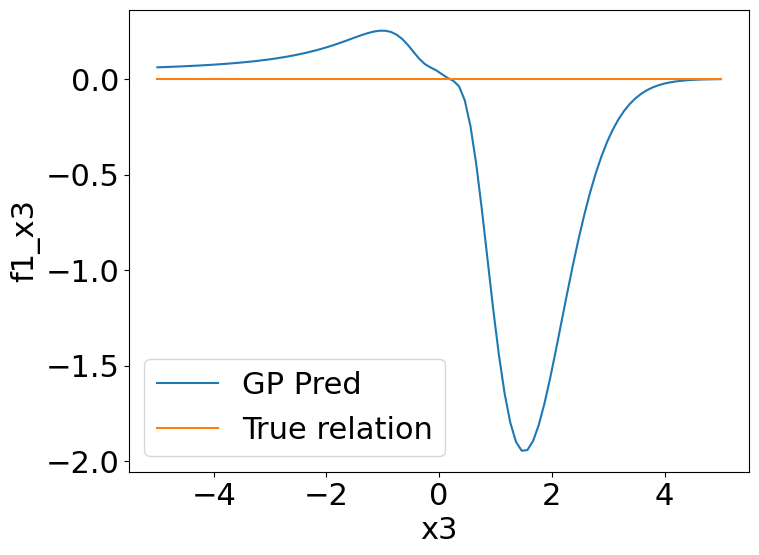

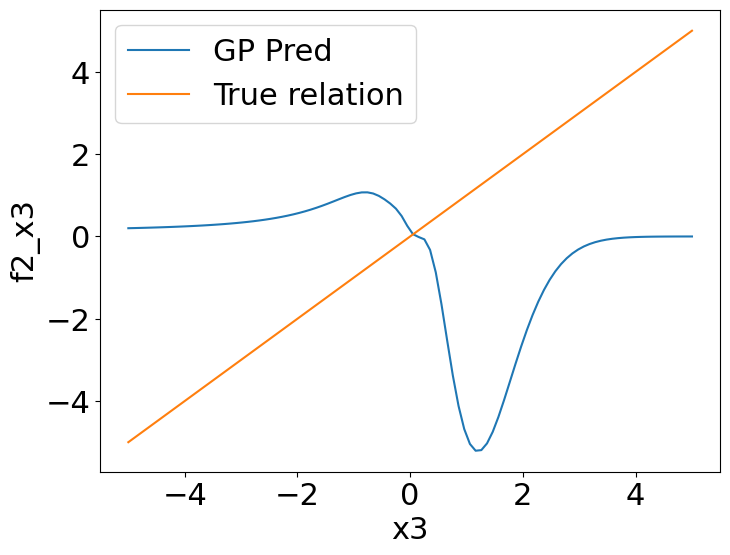

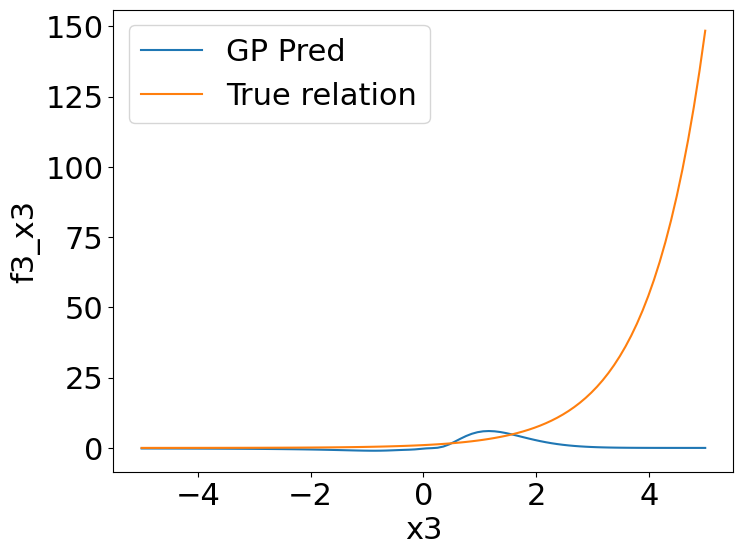

In [211]:
f_first_order2 = all_x3_effects @ Phi.T

for i in range(f_first_order2.shape[1]):
    plt.figure(figsize=(8,6))
    plt.plot(x3_plot_range_original, f_first_order2[:,i], label='GP Pred')
    if i == 0:
        true_f = np.zeros_like(x3_plot_range_original)
    elif i == 1:
        true_f = x3_plot_range_original
    else:
        true_f = np.exp(x3_plot_range_original)
        
    plt.plot(x3_plot_range_original, true_f ,label='True relation')
    plt.xlabel('x3')
    plt.ylabel(f'f{i+1}_x3')

    plt.legend()

plt.show()

In [246]:

# Not dependent on x3
def f_1(x1, x2, x3):
    return(5 * x1 + x2 ** 2 + x1 * x2)

# No second order terms
def f_2(x1, x2, x3):
    return(np.cos(x1) + x2 + x3 ** 2 + 5 * x1 * x2 * x3)

# all order terms
def f_3(x1, x2, x3):
    return(3 * np.abs(x1) + 2 * x2 + np.exp(x3) + 2* x1 * x2 + 5 * np.sin(x1* x3) + 0.25 * x2 * x3 + 5 * x1 * x2 * x3)

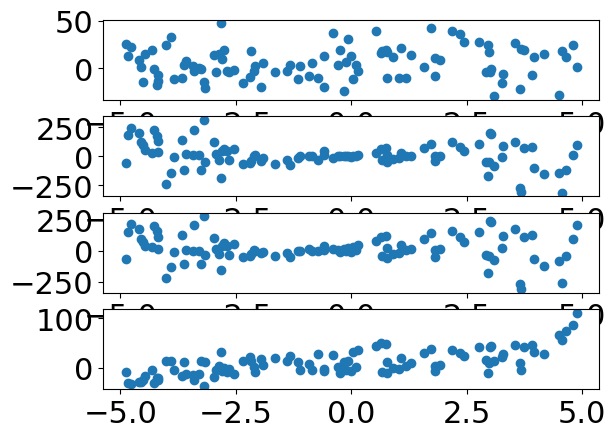

array([[ 1.        , -0.06125854, -0.01836248],
       [-0.06125854,  1.        ,  0.97051345],
       [-0.01836248,  0.97051345,  1.        ]])

In [253]:
fig, ax = plt.subplots(4, 1)
ax[0].scatter(x3, f_1(x1, x2, x3))
ax[1].scatter(x3, f_2(x1, x2, x3))
ax[2].scatter(x3, f_3(x1, x2, x3))
ax[3].scatter(x3, f_3(x1, x2, x3) - f_2(x1, x2, x3))

plt.show()

np.corrcoef(F_train.T)

In [235]:
x_test = np.linspace(X_LOWER, X_UPPER, 100)
X_test = np.column_stack((x_test, x_test, x_test))

g_1_preds = emulator_models[0].predict(X_train)
g_2_preds = emulator_models[1].predict(X_train)
g_3_preds = emulator_models[2].predict(X_train)

G = np.column_stack((g_1_preds, g_2_preds, g_3_preds))

phi_g = G @ Phi.T
print(sqrt(np.mean((phi_g - np.column_stack((f_1(x1, x2, x3), f_2(x1, x2, x3), f_3(x1, x2, x3))))**2))


12.971966011743941


1087.244492258263


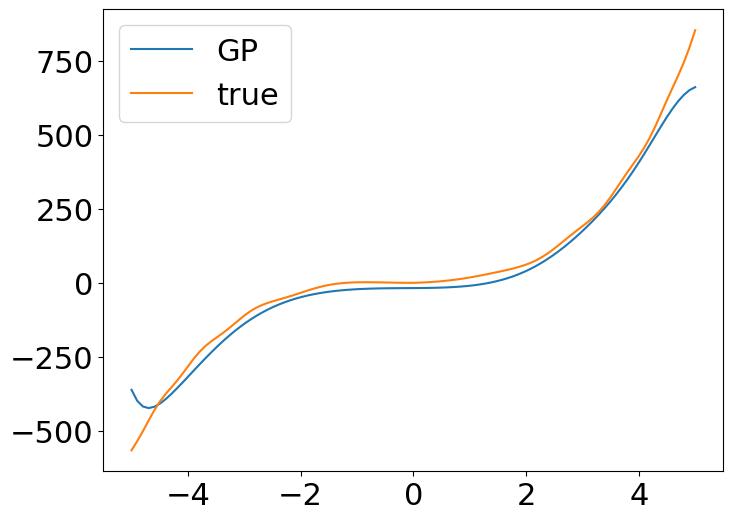

In [232]:
x_test = np.linspace(X_LOWER, X_UPPER, 100)
X_test = np.column_stack((x_test, x_test, x_test))

g_1_preds = emulator_models[0].predict(X_test)
g_2_preds = emulator_models[1].predict(X_test)
g_3_preds = emulator_models[2].predict(X_test)

G = np.column_stack((g_1_preds, g_2_preds, g_3_preds))

phi_g = G @ Phi.T
print(np.mean((phi_g - np.column_stack((f_1(x_test, x_test, x_test), f_2(x_test, x_test, x_test), f_3(x_test, x_test, x_test))))**2))


plt.figure(figsize=(8,6))
plt.plot(x_test, phi_g[:,2], label='GP')

plt.plot(x_test, f_3(x_test, x_test, x_test), label='true')
plt.legend()
plt.show()


(100, 3)

In [263]:
emulator_models[0].m

name,class,transform,prior,trainable,shape,dtype,value
GPR.kernel.kernels[0].base_kernel.lengthscales,Parameter,Sigmoid,,True,(),float64,1.1627
GPR.kernel.kernels[1].base_kernel.lengthscales,Parameter,Sigmoid,,True,(),float64,2.35125
GPR.kernel.kernels[2].base_kernel.lengthscales,Parameter,Sigmoid,,True,(),float64,1.1564
GPR.kernel.variances[0],Parameter,Softplus,Gamma,True,(),float64,0.00017
GPR.kernel.variances[1],Parameter,Softplus,Gamma,True,(),float64,0.03598
GPR.kernel.variances[2],Parameter,Softplus,Gamma,True,(),float64,0.04227
GPR.kernel.variances[3],Parameter,Softplus,Gamma,True,(),float64,16.7758
GPR.likelihood.variance,Parameter,Softplus + Shift,,True,(),float64,0.00046


In [265]:
emulator_models = [] 
for i in range(F_train.shape[1]):
    oak_model_instance = oak_model(max_interaction_depth=X_train.shape[1],
                                  use_normalising_flow=True,
                                  use_sparsity_prior=True)
    
    oak_model_instance.fit(X_train, F_train[:,i].reshape(-1,1))

    emulator_models.append(oak_model_instance)
    

indices of binary feature  []
indices of continuous feature  [0, 1, 2]
indices of categorical feature  []
[None, None, None]
Using sparsity prior


name,class,transform,prior,trainable,shape,dtype,value
GPR.kernel.kernels[0].base_kernel.lengthscales,Parameter,Sigmoid,,True,(),float64,0.70089
GPR.kernel.kernels[1].base_kernel.lengthscales,Parameter,Sigmoid,,True,(),float64,0.94074
GPR.kernel.kernels[2].base_kernel.lengthscales,Parameter,Sigmoid,,True,(),float64,1000
GPR.kernel.variances[0],Parameter,Softplus,Gamma,True,(),float64,0.00248
GPR.kernel.variances[1],Parameter,Softplus,Gamma,True,(),float64,1.2543
GPR.kernel.variances[2],Parameter,Softplus,Gamma,True,(),float64,0.24345
GPR.kernel.variances[3],Parameter,Softplus,Gamma,True,(),float64,0
GPR.likelihood.variance,Parameter,Softplus + Shift,,True,(),float64,0


Training took 1.4 seconds.
indices of binary feature  []
indices of continuous feature  [0, 1, 2]
indices of categorical feature  []
[None, None, None]
Using sparsity prior


name,class,transform,prior,trainable,shape,dtype,value
GPR.kernel.kernels[0].base_kernel.lengthscales,Parameter,Sigmoid,,True,(),float64,1.06352
GPR.kernel.kernels[1].base_kernel.lengthscales,Parameter,Sigmoid,,True,(),float64,2.14349
GPR.kernel.kernels[2].base_kernel.lengthscales,Parameter,Sigmoid,,True,(),float64,1.12268
GPR.kernel.variances[0],Parameter,Softplus,Gamma,True,(),float64,0.00024
GPR.kernel.variances[1],Parameter,Softplus,Gamma,True,(),float64,0.00731
GPR.kernel.variances[2],Parameter,Softplus,Gamma,True,(),float64,0.04449
GPR.kernel.variances[3],Parameter,Softplus,Gamma,True,(),float64,12.8572
GPR.likelihood.variance,Parameter,Softplus + Shift,,True,(),float64,0.00014


Training took 1.3 seconds.
indices of binary feature  []
indices of continuous feature  [0, 1, 2]
indices of categorical feature  []
[None, None, None]
Using sparsity prior


name,class,transform,prior,trainable,shape,dtype,value
GPR.kernel.kernels[0].base_kernel.lengthscales,Parameter,Sigmoid,,True,(),float64,1.32199
GPR.kernel.kernels[1].base_kernel.lengthscales,Parameter,Sigmoid,,True,(),float64,2.28283
GPR.kernel.kernels[2].base_kernel.lengthscales,Parameter,Sigmoid,,True,(),float64,1.10682
GPR.kernel.variances[0],Parameter,Softplus,Gamma,True,(),float64,0
GPR.kernel.variances[1],Parameter,Softplus,Gamma,True,(),float64,0.19333
GPR.kernel.variances[2],Parameter,Softplus,Gamma,True,(),float64,0.04045
GPR.kernel.variances[3],Parameter,Softplus,Gamma,True,(),float64,17.4069
GPR.likelihood.variance,Parameter,Softplus + Shift,,True,(),float64,0.00133


Training took 1.3 seconds.
